# Monte Carlo Sampling

The `MonteCarlo` class generates synthetic debris disc particle positions via orbital sampling from an input surface density profile $\Sigma_a(a)$ and an eccentricity distribution $\psi(e, a)$. It supports both unique eccentricity profiles and general distributions. 

This is particularly useful for validating the ASD results obtained through the main semi-analytic pipeline. 

## Sampling the 1D $\bar\Sigma(r)$ Profile

The Monte Carlo approach enables the estimation of the azimuthally symmetric surface density profile, $\bar\Sigma(r)$, by generating and binning random samples of orbital positions. This method is especially useful for validating analytical results or for exploring eccentricity distributions that are difficult or inefficient to integrate directly.

To begin, the `MonteCarlo` object is initialised by passing in the pre-defined `SigmaA` and `Eccentricity` objects. These are the same as those used in the main analytical pipeline, ensuring a cohesive and consistent modelling framework.

Once initialised, samples can be generated by calling the `sampler()` method. Internally, this first samples particle semi-major axes, $a$, from the distribution $\Sigma_a(a)$, using rejection sampling. When computing a 1D radial profile, the user must sample from the distribution $a_i \sim \Sigma_a(a) \cdot a$, where the additional factor of $a$ arises from the coordinate transformation Jacobian (enforcing mass conservation). The user can control this behaviour with the `use_jacobian=True` flag (enabled by default).

The method then proceeds to draw eccentricities and solve Kepler’s equation to obtain the corresponding radial distances, $r$. We refer the reader to the API documentation for full details of this internal calculation.

Setting `verbose=True` provides real-time feedback on the sampling progress. Additionally, by enabling `return_samples=True`, the function returns the following arrays:

- `a_samples`: Semi-major axis values drawn from $\Sigma_a(a)$.
- `r_samples`: Radial positions calculated from each $(a, e, f)$ sample.
- `e_samples`: Eccentricities sampled from the specified eccentricity profile.
- `f_samples`: True anomalies corresponding to each orbit.

These arrays can be used to visualise or analyse the distribution of sampled orbits, and to construct histograms approximating $\bar\Sigma(r)$.

### Unique Eccentricity Profile

In the unique eccentricity case, $e=e(a)$, the eccentricity for each particle is trivially computed once the semi-major axis positions have been sampled.

In [16]:
from debrispy import SigmaA, UniqueEccentricity, MonteCarlo

# Initialise the surface density profile and eccentricity profile
sigma_a = SigmaA(a_min = 1, a_max = 4, sigma0 = 1, power = 0.5)
ecc_profile = UniqueEccentricity(a_min = 1, a_max = 4, e0 = 0.5, power = 0.7)

# Initialise the Monte Carlo Sampler
mc = MonteCarlo(sigma_a, ecc_profile, n_samples = 1_000_000)

# Sample the 1D profile
a_samples, r_samples, e_samples, f_samples = mc.sampler(use_jacobian = True, verbose = True, return_samples = True)

Sampling semi-major axis...
Sampling eccentricities...
Solving Kepler's equation...
Done.


If `return_samples=False`, the samples are not returned as arrays, and are instead only stored internally within the object.

In [17]:
# Sample the 1D profile without returning values
mc.sampler(use_jacobian = True, verbose = True, return_samples = False)

Sampling semi-major axis...
Sampling eccentricities...
Solving Kepler's equation...
Done.


### Obtaining 1D Histograms

When generating 1D histograms from the Monte Carlo samples, the raw counts per bin does not yet represent a surface density profile. To obtain physical surface densities, each bin must be normalised by its geometric factor: 

- For $\Sigma_a(a)$, divide by $a$,
- For $\bar\Sigma(r)$, divide by $r$.

This accounts for the Jacobian of the coordinate transformation and ensures the histograms represent *surface density per unit distance*, rather than raw particle counts.

The method `get_1d_histogram` automates this process. It returns two `Histogram1D` objects, corresponding to $\Sigma_a(a)$ and $\bar\Sigma(r)$ respectively.

The user selects the number of bins to use (defaulting to 500). The optional argument scale=True (enabled by default) rescales the histograms so that their integrals match the analytical mass implied by the chosen $\Sigma_a(a)$ profile. This preserves the total mass consistency between the Monte Carlo realisation and the analytic profile.

In [18]:
histA, histR = mc.get_1d_histogram(bins = 500, scale = True)

### `Histogram1D` Class

A `Histogram1D` is a lightweight container which stores:

- `edges`: the bin edges
- `values`: the bin values
- `kind`: either `a` for $\Sigma_a(a)$ or `r` for $\bar\Sigma(r)$
- `scaled`: whether global rescaling to match analytic mass was applied

It also provides convenient properties and methods:

- `centers:` returns bin centers
- `widths`: returns bin widths
- `as_tuple_centers`: returns (centers, values) for plotting purposes
- `as_tuple_edges`: returns (edges, values) for rebinning purposes
- `plot`: plotting tool for easy visualisation|

### Visualising the Results

#### Visualisation Method 1: `MonteCarlo.plot_1d`

This will plot both the semi-major axis profile $\Sigma_a(a)$ and the sampled radial profile $\bar\Sigma(r)$, using 500 bins by default. Several keyword options allow for further customisation:

- `bins` (`int`): Number of bins used in both histograms. Default is `500`.

- `save` (`bool`): If `True`, saves the plot to disk. Requires `filepath` to be specified.

- `filepath` (`str`): Path to save the figure if `save=True`.

- `overlay` (`bool`): If `True`, overlays the sampled profile with the analytic result from the `ASD` class for comparison (requies the user to supply the precomputed ASD).

- `scale` (`bool`): If `True`, normalises histograms to match the area under the analytic $\Sigma_a(a)$ curve.

- `asd` (`ASD` object): Optional. If provided and `overlay=True`, this analytic profile is plotted alongside the Monte Carlo results.

- `x_lim`, `y_lim` (`tuple`): Optional axis limits for more controlled visual output.

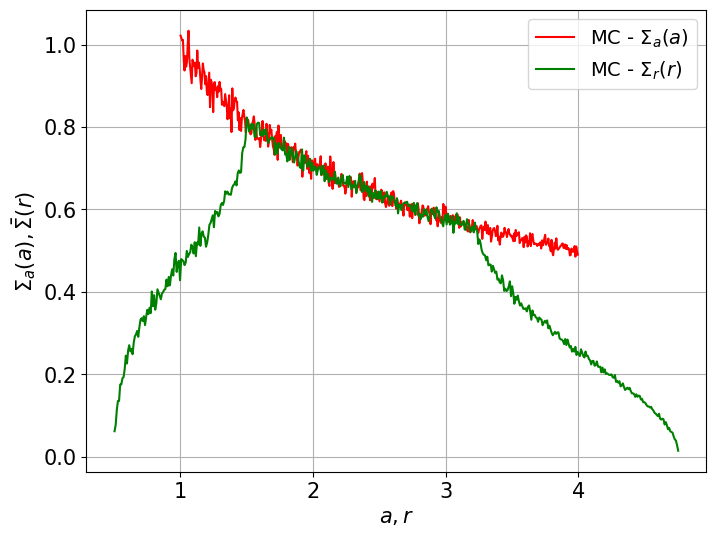

In [19]:
mc.plot_1d(bins = 500, scale = True, overlay = False)

In order to overlay the ASD, the user needs to compute it separately.

In [20]:
import numpy as np
from debrispy import Kernel, ASD

kernel = Kernel(ecc_profile, r_min = 0.01, r_max = 5)
kernel.compute()

asd = ASD(kernel, sigma_a)
asd.compute_gl(r_vals = np.linspace(0.01, 5, 500), n_points = 128, n_jobs = -1, show_progress = False)

Computing ASD with Gauss-Legendre (with fixed limits)...
Done. Final result has 500 valid points.



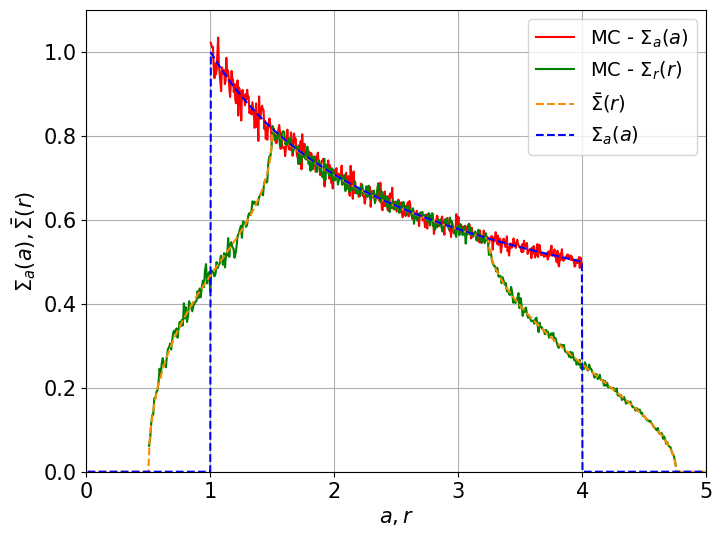

In [21]:
mc.plot_1d(overlay = True, asd = asd, x_lim=(0, 5), y_lim=(0, 1.1))

#### Visualisation Method 2: `Histogram1D.plot`

Since `get_1d_histogram` returns two `Histogram1D` objects (e.g., `histA`, `histR`), each has its own `.plot()` method for individual visualisation. This gives more granular control and allows easy integration into custom figures:

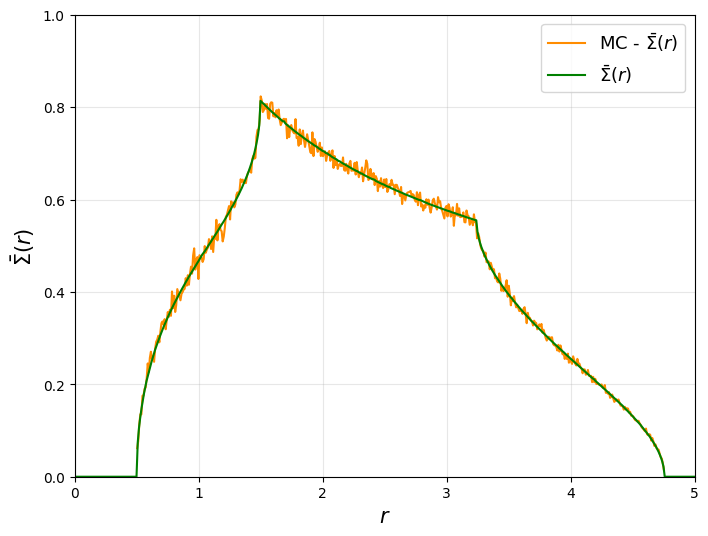

In [31]:
import matplotlib.pyplot as plt

# Plot the Monte Carlo histogram
ax = histR.plot(label=r"MC - $\bar{\Sigma}(r)$", color="darkorange")

# Overlay the analytic profile
asd_r, asd_vals = asd.get_values()
ax.plot(asd_r, asd_vals, label=r"$\bar{\Sigma}(r)$", color="green")

# Final touches
ax.legend(fontsize=13)
ax.set_xlabel(r"$r$", fontsize=15)
ax.set_ylabel(r"$\bar{\Sigma}(r)$", fontsize=15)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 5)
ax.set_ylim(0, 1)
plt.show()

This design separates data handling (via `Histogram1D` containers) from visualisation, making it easier to reuse the same histogram objects in different plotting contexts.

### Eccentricity Distribution

The method and user interface remain identical when the provided eccentricity profile is a distribution, $\psi(e, a)$. The only difference lies in how eccentricities are sampled. 

In the unique eccentricity case, the eccentricity for each particle is deterministically computed from a fixed function. However, when using a distribution, the eccentricity **must be sampled individually** for each particle based on its semi-major axis. That is, for each sampled value $a_i$, the corresponding eccentricity is drawn from a conditional distribution:

$$
e_i \sim \psi(e \mid a_i)
$$

This makes the sampling process inherently more computationally expensive than the unique case, as it requires evaluating the distribution and performing rejection sampling for each individual particle.


In [32]:
from debrispy import SigmaA, RayleighEccentricity, MonteCarlo

disc = SigmaA(a_min=1, a_max=4, sigma_0=1, power=0.5, profile_type="power_law")
ecc_rayleigh = RayleighEccentricity(1, 4, sigma0=0.4, power=0.5)

mc = MonteCarlo(disc, ecc_rayleigh, n_samples=1_000_000)
a_samples, r_samples, e_samples, f_samples = mc.sampler(use_jacobian = True)

Sampling semi-major axis...
Sampling eccentricities...
Solving Kepler's equation...
Done.


In [33]:
kernel = Kernel(ecc_rayleigh, r_min = 0.01, r_max = 6)
kernel.compute()

asd = ASD(kernel, disc)
asd.compute_gl(r_vals = np.linspace(0.01, 6, 500), n_points = 64, n_jobs = -1, show_progress = False)

Computing ASD with Gauss-Legendre (with fixed limits)...
Done. Final result has 500 valid points.



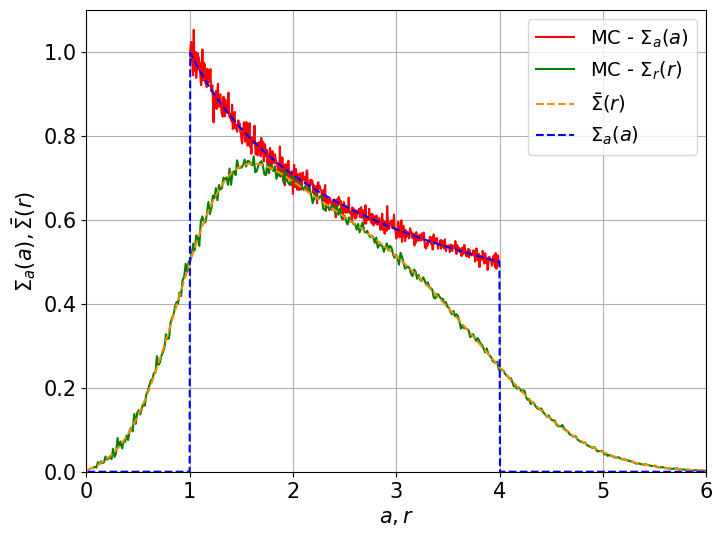

In [34]:
mc.plot_1d(overlay = True, scale = True, asd = asd, x_lim=(0, 6), y_lim=(0, 1.1))

## Sampling the Full $\Sigma(r, \phi)$ Distribution

In addition to the 1D surface density profile, the Monte Carlo sampler can be used to reconstruct the full 2D spatial distribution $\Sigma(r, \phi)$. 

To generate this 2D distribution, the user can use the same `sampler` method as before. However, for the 2D case, **the Jacobian factor must be omitted**, `use_jacobian = False`.

This is because $\Sigma(r, \phi)$ represents particle counts in physical space rather than mass conservation in annular shells, therefore the Jacobian weighting for mass conservation (used in 1D) is not required here.

In [3]:
sigma_a = SigmaA(a_min = 1, a_max = 6, sigma0 = 1, power = 0.5)
ecc_profile = UniqueEccentricity(a_min = 1, a_max = 6, e0 = 0.5, power = 0.7)

mc = MonteCarlo(sigma_a, ecc_profile, n_samples = 50_000_000)
mc.sampler(use_jacobian = True, verbose = True, return_samples = False)

Sampling semi-major axis...
Sampling eccentricities...
Solving Kepler's equation...
Done.


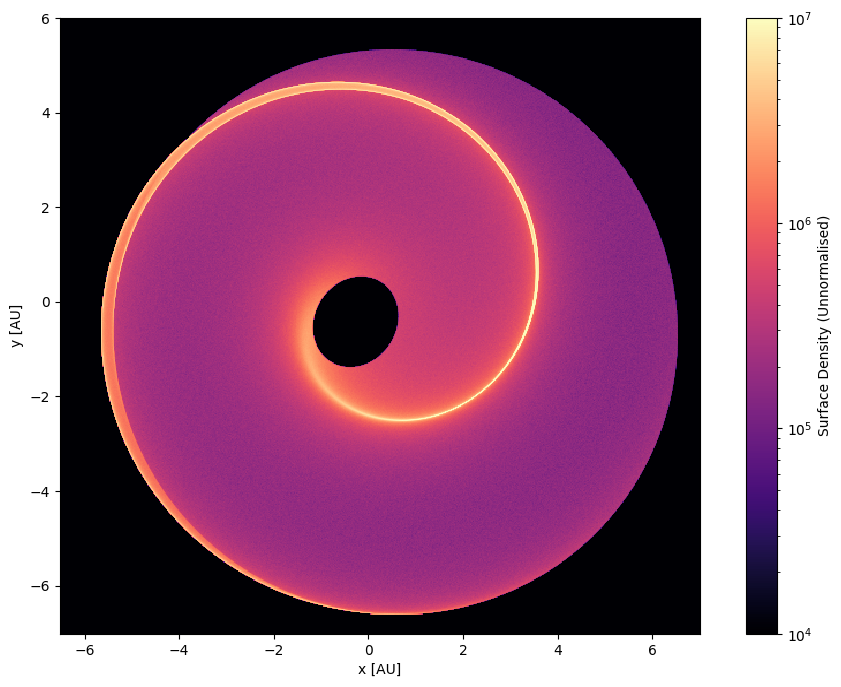

In [ ]:
def varpi_func(a):
    return a**1.2

hist_cart = mc.get_cart_histogram(bins = 500, varpi_func=varpi_func, surface_density = True)
# hist_polar = mc.get_polar_histogram(bins = 500, varpi_func=varpi_func, surface_density = True)

# mc.plot_2d(varpi_func=varpi_func, bins=500, mode='cartesian', save=False, floor_threshold= 1e-4, floor_value = 1, xlim = (-6, 7), ylim = (-7, 6), surface_density = True, vmin = 1e4, vmax = 1e7)

hist_cart_conv = hist_cart.convolve_gaussian(fwhm_x = 1.2, fwhm_y = 0.2, theta = np.pi/4)
ax = hist_cart_conv.plot(log = True, vmin = 1e4, vmax = 1e7, floor_threshold= 1, floor_value = 1e-10, xlim = (-6.5, 7), ylim = (-7, 6), cbar_label = "Surface Density (Unnormalised)", save = True, filepath = "monte_carlo_cartesian.png")

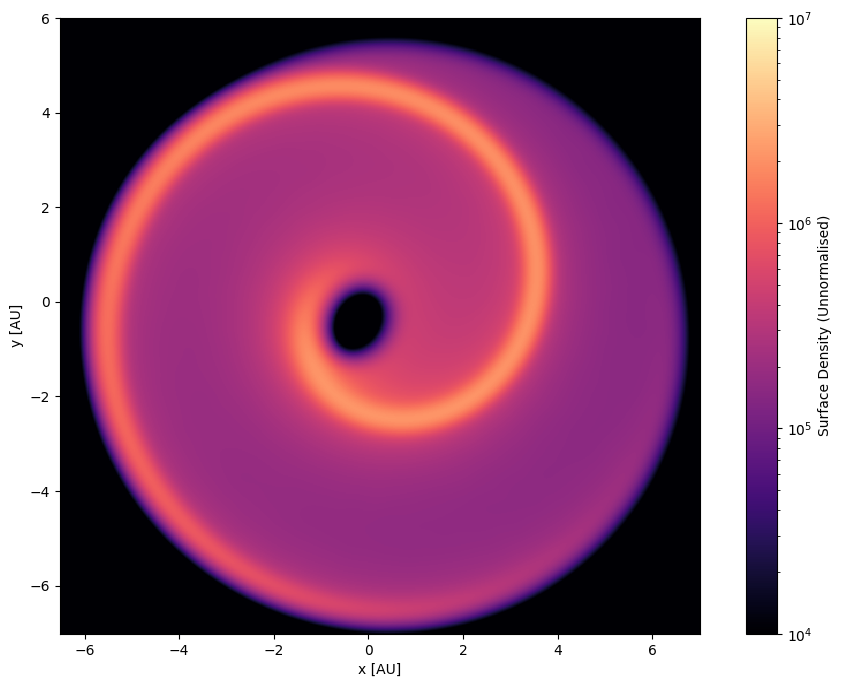

In [37]:
def varpi_func(a):
    return a**1.2

hist_cart = mc.get_cart_histogram(bins = 500, varpi_func=varpi_func, surface_density = True)
# hist_polar = mc.get_polar_histogram(bins = 500, varpi_func=varpi_func, surface_density = True)

# mc.plot_2d(varpi_func=varpi_func, bins=500, mode='cartesian', save=False, floor_threshold= 1e-4, floor_value = 1, xlim = (-6, 7), ylim = (-7, 6), surface_density = True, vmin = 1e4, vmax = 1e7)

hist_cart_conv = hist_cart.convolve_gaussian(fwhm_x = 0.4, fwhm_y = 0.4, theta = np.pi/4)

ax = hist_cart_conv.plot(log = True, vmin = 1e4, vmax = 1e7, floor_threshold= 1, floor_value = 1e-10, xlim = (-6.5, 7), ylim = (-7, 6), cbar_label = "Surface Density (Unnormalised)", save = True, filepath = "blur1.png")

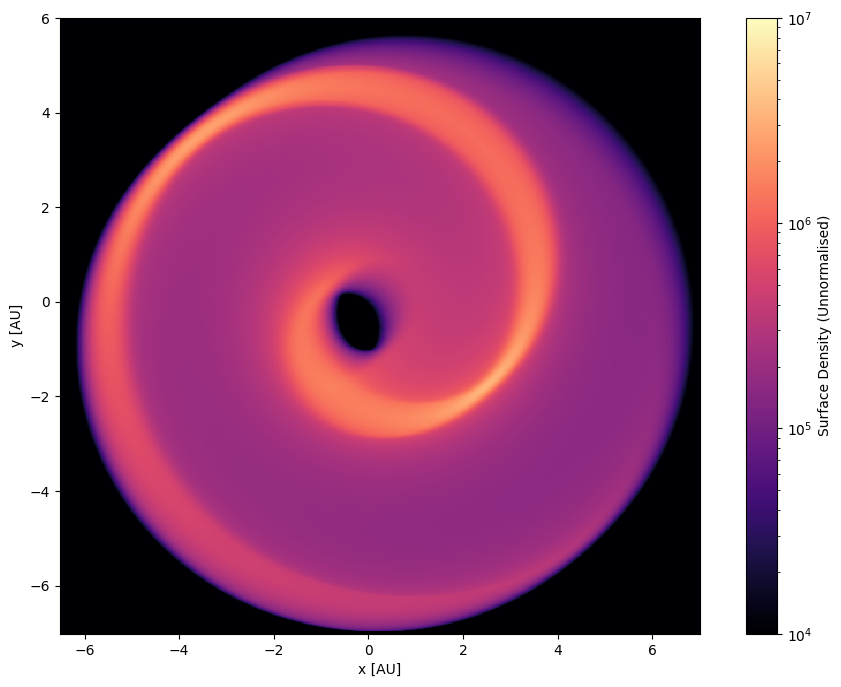

In [38]:
import numpy as np

hist_cart_conv = hist_cart.convolve_gaussian(fwhm_x = 1.2, fwhm_y = 0.2, theta = np.pi/4)
ax = hist_cart_conv.plot(log = True, vmin = 1e4, vmax = 1e7, floor_threshold= 1, floor_value = 1e-10, xlim = (-6.5, 7), ylim = (-7, 6), cbar_label = "Surface Density (Unnormalised)", save=True, filepath = "blur2.png")

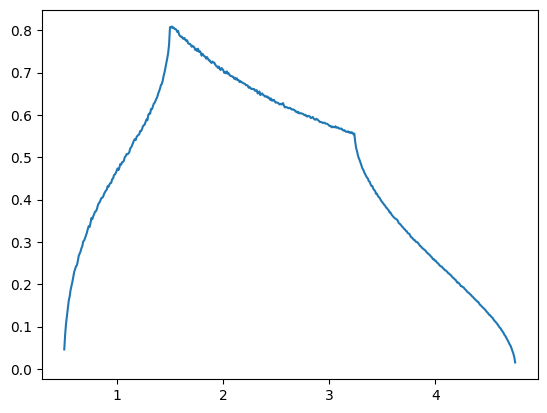

In [41]:
import matplotlib.pyplot as plt
from numpy import trapz


V = hist_polar.values              # shape (Nphi, Nr)
r_edges = hist_polar.r_edges
phi_edges = hist_polar.phi_edges

r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])   # (Nr,)
barSigma = V.sum(axis=0)                         # (Nr,)

# Current integral (area under the curve)
area = trapz(barSigma, x=r_centers)

# Scale factor so that area = 2
target_area = 2.0
scale = target_area / area

barSigma_norm = barSigma * scale


plt.plot(r_centers, barSigma_norm)
plt.show()

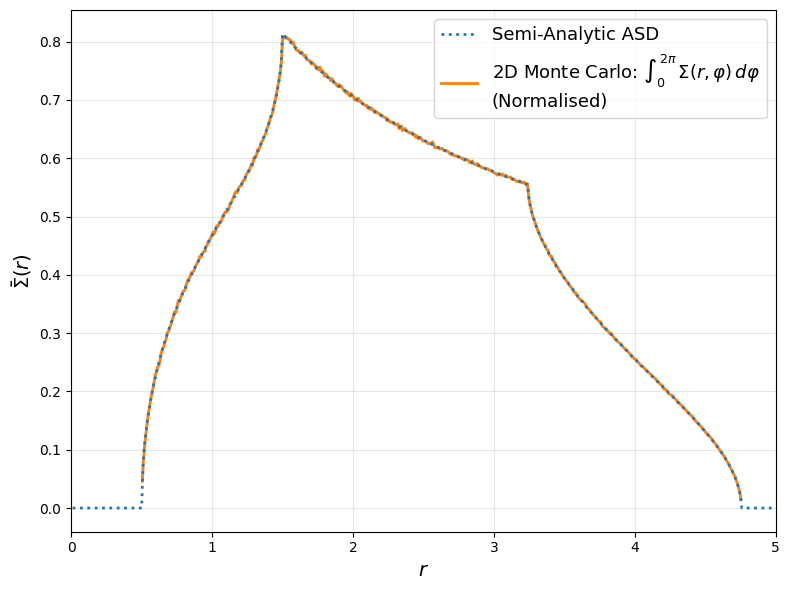

In [84]:
r_asd, vals_asd = asd.get_values()
fig, ax = plt.subplots(figsize = (8, 6))


ax.plot(r_asd, vals_asd, ':', lw = 2, zorder = 10, label = "Semi-Analytic ASD")
ax.plot(r_centers, barSigma_norm, lw=2, label=r"2D Monte Carlo: $\int_0^{2\pi} \, \Sigma(r, \varphi) \, d\varphi$" + "\n(Normalised)")
ax.legend(fontsize = 13)
ax.set_xlabel(r"$r$", fontsize = 14)
ax.set_ylabel(r"$\bar\Sigma(r)$", fontsize = 14)
ax.grid(True, alpha = 0.3)
ax.set_xlim(0, 5)
plt.tight_layout()
plt.savefig("monte_carlo_vs_asd.png", dpi = 300)
plt.show()

In [20]:
disc = SigmaA(1, 6, profile_type = 'power_law', power = 0.5)
ecc = UniqueEccentricity(1, 6, e0=0.5, power=0.7)
mc = MonteCarlo(disc, ecc, n_samples=50_000_000)

mc.sampler(use_jacobian = True, verbose = True, return_samples = False)

Sampling semi-major axis...
Sampling eccentricities...
Solving Kepler's equation...
Done.


In order to convert the $r$ samples obtained from the `sampler` into 2D spatial distributions, the user must provide the functional form of the apsidal angle, $\varpi(a)$.

We provide two functions to construct 2D histograms, `get_polar_histogram` to get the histogram in $(r, \phi)$ coordinates and `get_cart_histogram` to get the histogram in $(x, y)$ coordinates.

The bins argument defines the resolution along each axis, e.g., `bins=500` results in a 500×500 histogram in both the polar and Cartesian cases.

In [21]:
def varpi_func(a):
    return a**(1.2)

hist_polar = mc.get_polar_histogram(bins = 500, varpi_func=varpi_func)
hist_cart = mc.get_cart_histogram(bins = 500, varpi_func=varpi_func)

In [4]:
import numpy as np

hist_cart_conv = hist_cart.convolve_gaussian(fwhm_x = 0.2, fwhm_y = 0.1, theta = 0)

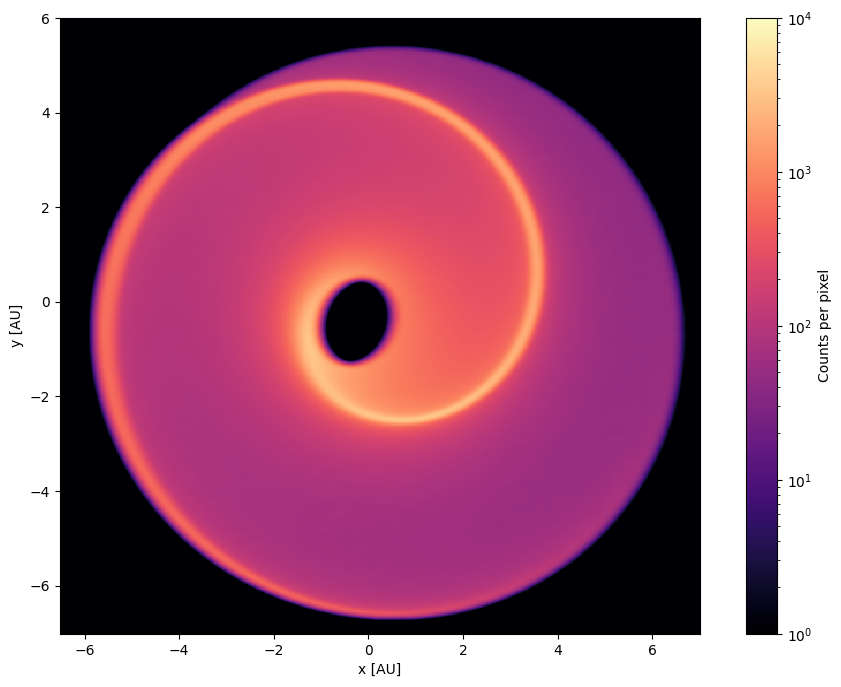

In [5]:
ax = hist_cart_conv.plot(log = True, vmin = 1, vmax = 1e4, floor_threshold= 1, floor_value = 1e-10, xlim = (-6.5, 7), ylim = (-7, 6))

Generating 2D histogram in cartesian coordinates...


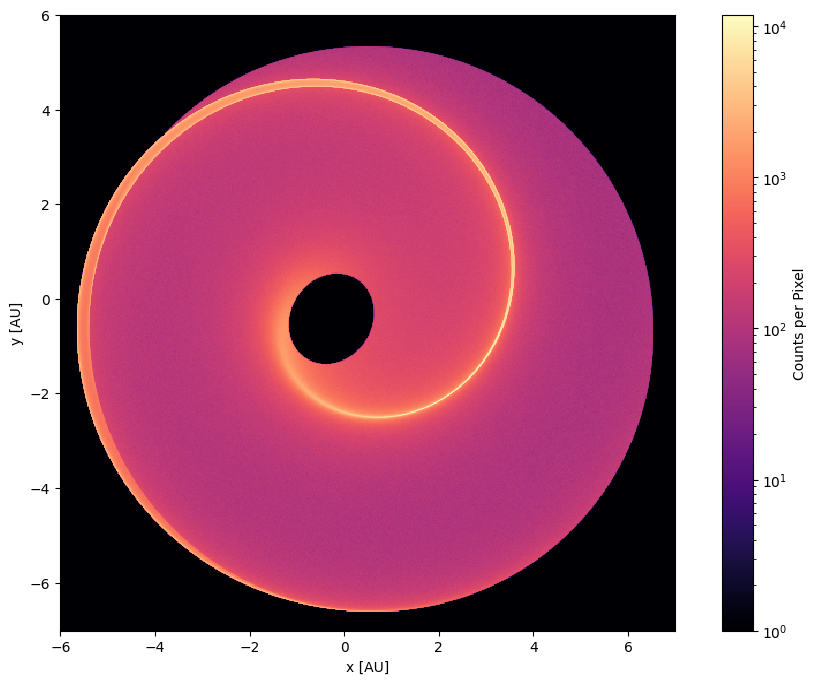

In [22]:
mc.plot_2d(varpi_func=varpi_func, bins=500, mode='cartesian', save=False, floor_threshold= 1e-4, floor_value = 1, xlim = (-6, 7), ylim = (-7, 6), surface_density = False)

Generating 2D histogram in cartesian coordinates...


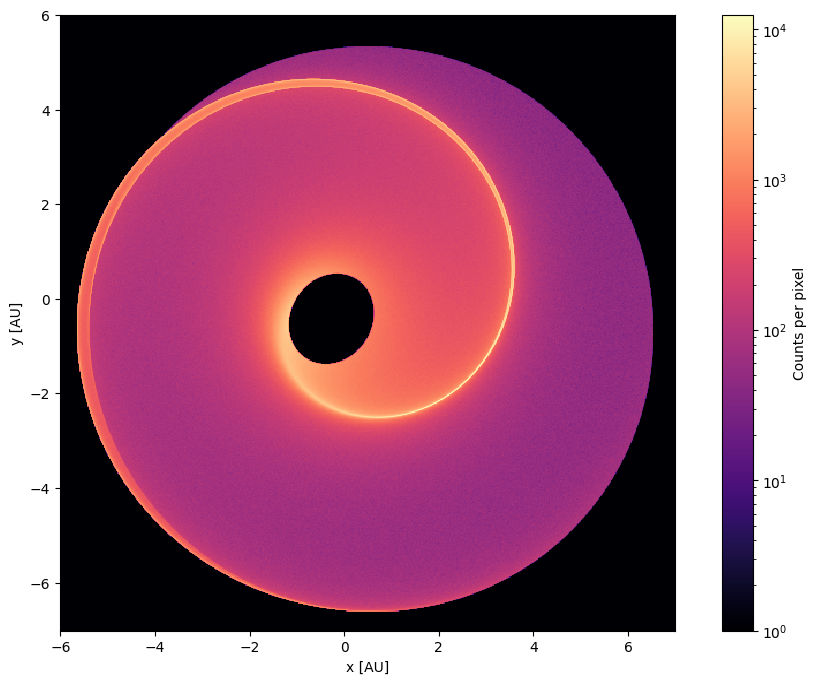

In [6]:
mc.plot_2d(varpi_func=varpi_func, bins=500, mode='cartesian', save=False, floor_threshold= 1e-4, floor_value = 1, xlim = (-6, 7), ylim = (-7, 6))

<Axes: xlabel='x [AU]', ylabel='y [AU]'>

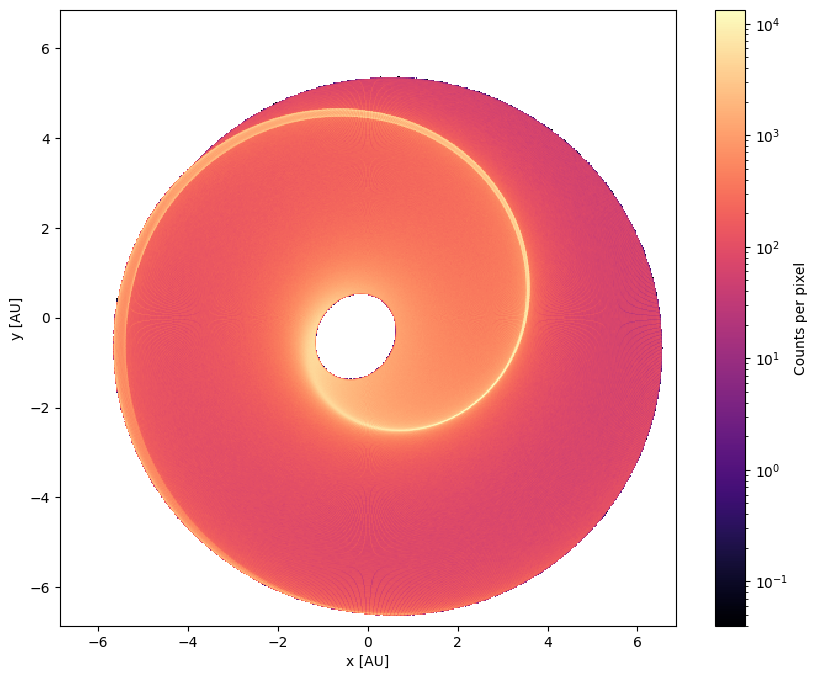

In [5]:
hist_cart = hist_polar.to_cartesian(bins = 500, supersample = 5)
hist_cart.plot(log = True)

<Axes: xlabel='r [AU]', ylabel='$\\phi$ [rad]'>

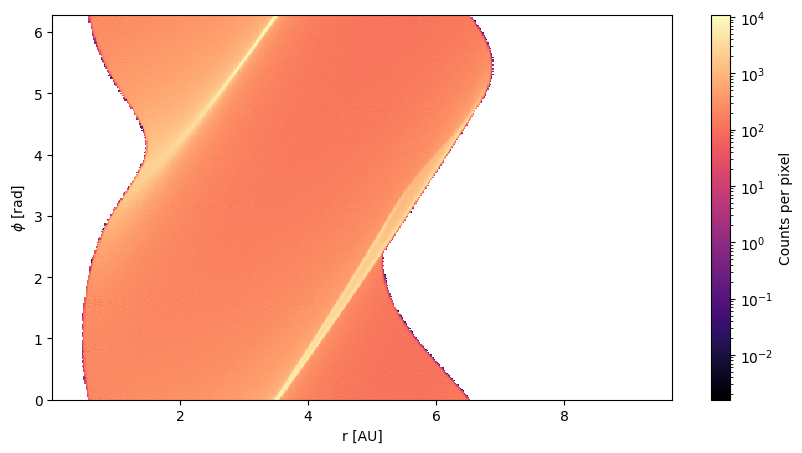

In [6]:
hist_polar = hist_cart.to_polar(bins = 500, supersample = 5)
hist_polar.plot(log = True)

These histograms can be visualised using the `plot_2d` method. The user can control the output through several keyword arguments:

- `varpi_func` (callable, optional): Function that maps semi-major axis `a` to apsidal angle $\varpi(a)$.

- `bins` (int): Number of bins in the histogram (effectively n x n).

- `log` (bool): If `True`, applies logarithmic colour scaling for better contrast in regions of low particle density.

- `mode` (str): Choose between `'cartesian'` and `'polar'` views.  

  - `'cartesian'` plots the 2D density in $x$–$y$ space.  
  - `'polar'` plots in $r$–$\phi$ space.

- `save` (bool): If `True`, saves the resulting figure. Requires `filepath` to be specified.

- `filepath` (str or Path, optional): File path to save the figure if `save=True`.

Generating 2D histogram in cartesian coordinates...


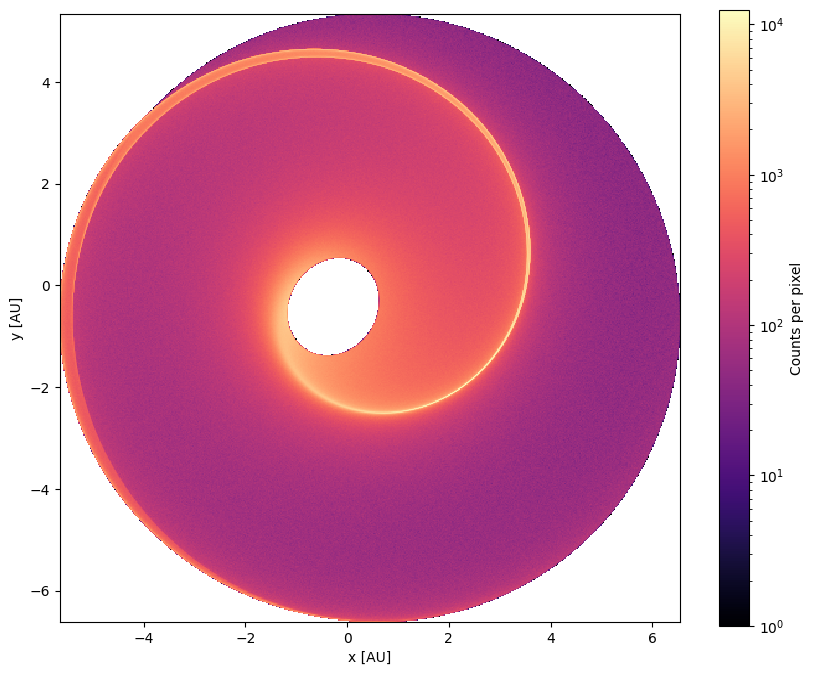

In [7]:
mc.plot_2d(varpi_func=varpi_func, bins=500, mode='cartesian', save=False)

Generating 2D histogram in polar coordinates...


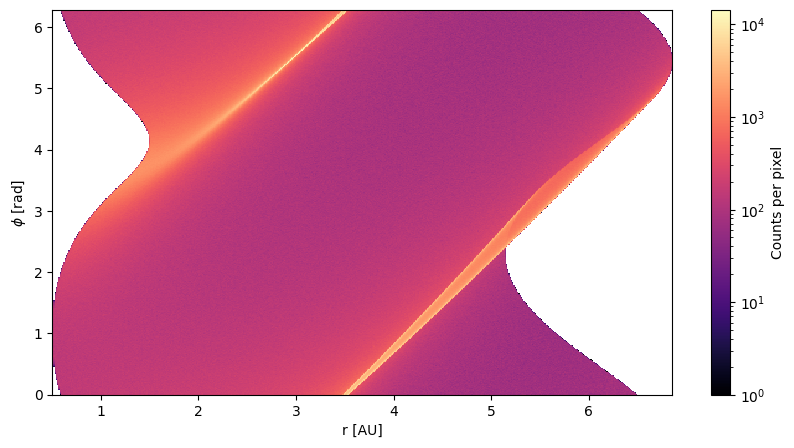

In [5]:
mc.plot_2d(varpi_func=varpi_func, bins=500, mode='polar', save=False)